# HR Data Analysis

In [7]:
# import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [142]:
# Load HR Data

df = pd.read_csv(r"Company Data.csv", encoding="unicode_escape")

In [17]:
# Check Number of  Rows and Columns
df.shape


(1470, 24)

In [144]:
# To see Imported Data 
df.head()

,ï»¿Employee Number,Attrition,Business Travel,Age Group,Department,Education Field,Employee Count,Gender,Job Role,Marital Status,...,Environment Satisfaction,Job Level,Job Satisfaction,Monthly Income,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
0,1,Yes,Travel_Rarely,35 - 44,Sales,Life Sciences,1,Female,Sales Executive,Single,...,2,2,4,5993,8,1,6,4,0,5
1,2,No,Travel_Frequently,45 - 54,R&D,Life Sciences,1,Male,Research Scientist,Married,...,3,2,2,5130,10,3,10,7,1,7
2,3,Yes,Travel_Rarely,35 - 44,R&D,Other,1,Male,Laboratory Technician,Single,...,4,1,3,2090,7,3,0,0,0,0
3,4,No,Travel_Frequently,25 - 34,R&D,Life Sciences,1,Female,Research Scientist,Married,...,4,1,3,2909,8,3,8,7,3,0
4,5,No,Travel_Rarely,25 - 34,R&D,Medical,1,Male,Laboratory Technician,Married,...,1,1,2,3468,6,3,2,2,2,2


In [37]:
# Filled Details and Data Type

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ï»¿Employee Number          1470 non-null   int64 
 1   Attrition                   1470 non-null   object
 2   Business Travel             1470 non-null   object
 3   Age Group                   1470 non-null   object
 4   Department                  1470 non-null   object
 5   Education Field             1470 non-null   object
 6   Employee Count              1470 non-null   int64 
 7   Gender                      1470 non-null   object
 8   Job Role                    1470 non-null   object
 9   Marital Status              1470 non-null   object
 10  Over Time                   1470 non-null   object
 11  Age                         1470 non-null   int64 
 12  Distance From Home          1470 non-null   int64 
 13  Education                   1470 non-null   obje

In [39]:
# Use describe for Specific Columns

df[["Age", "Monthly Income","Total Working Years", "Years At Company", "Years With Curr Manager"]].describe()

,Age,Monthly Income,Total Working Years,Years At Company,Years With Curr Manager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,6502.931293,11.279592,7.008163,4.123129
std,9.135373,4707.956783,7.780782,6.126525,3.568136
min,18.000000,1009.000000,0.000000,0.000000,0.000000
25%,30.000000,2911.000000,6.000000,3.000000,2.000000
50%,36.000000,4919.000000,10.000000,5.000000,3.000000
75%,43.000000,8379.000000,15.000000,9.000000,7.000000
max,60.000000,19999.000000,40.000000,40.000000,17.000000


## EDA - Exploratory Data Analysis

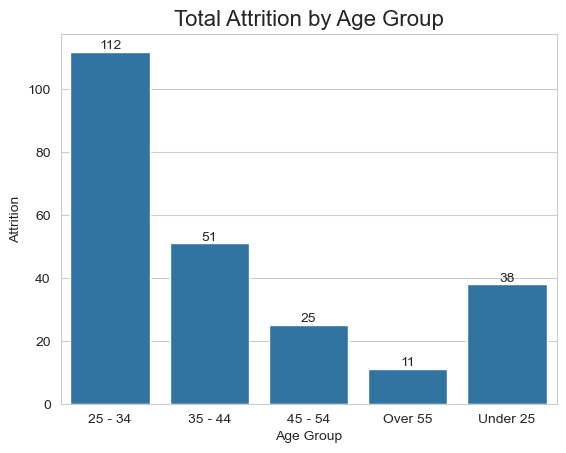

In [166]:
# Total Attrition by Age Group 

AgeGroup_Attrition = df[df["Attrition"] == "Yes"].groupby("Age Group", as_index=False)["Attrition"].count()

ax = sns.barplot(x="Age Group", y="Attrition", data=AgeGroup_Attrition)

for bar in ax.containers:
    ax.bar_label(bar)
    ax.set_title("Total Attrition by Age Group", size=16)

plt.show()

#### The highest attrition was observed among employees in the 25–34 and 35–44 age groups.

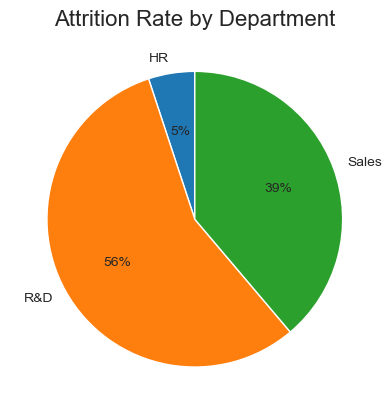

In [164]:
# Department wise Attrition Rate

Dept_Attrition = df[df["Attrition"] == "Yes"].groupby("Department")["Attrition"].count()

plt.pie(
    Dept_Attrition,
    labels = Dept_Attrition.index,
    autopct = "%.0f%%",
    startangle = 90
    )

plt.title("Attrition Rate by Department", size=16)
plt.show()


#### The R&D department contributed the highest employee attrition compared to other departments.

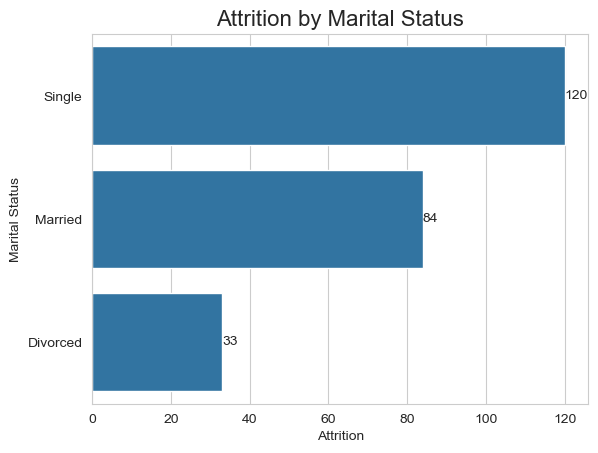

In [163]:
# Total Attrition by Martial Status

Marital_By_Attrition = df[df["Attrition"] == "Yes"].groupby("Marital Status", as_index=False)["Attrition"].count().sort_values(by=["Attrition"], ascending=False)

ax = sns.barplot(y="Marital Status", x="Attrition", data = Marital_By_Attrition)
for bar in ax.containers:
    ax.bar_label(bar)


plt.title("Attrition by Marital Status", size=16)
plt.show()


#### Single employees showed the highest attrition count among all marital status categories.

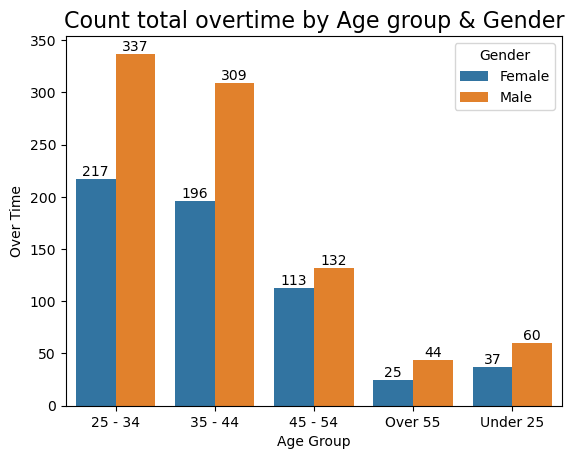

In [84]:
# Count Total Overtime by Age Group & Gender

GA_Overtime = df.groupby(["Age Group", "Gender"], as_index=False)["Over Time"].count().sort_values(by=["Age Group"], ascending=True)


ax = sns.barplot(x="Age Group", y="Over Time", hue="Gender",  data = GA_Overtime)
for bar in ax.containers:
    ax.bar_label(bar)


plt.title("Count total overtime by Age group & Gender", size=16)
plt.show()



#### Male employees in the 25–34 and 35–44 age groups showed the highest overtime participation.

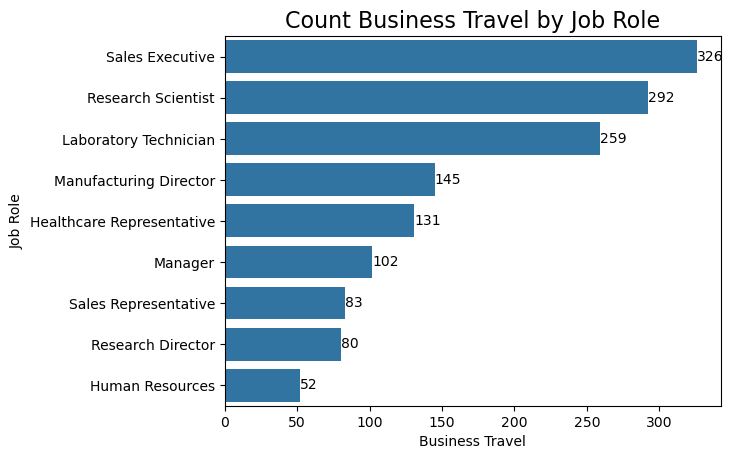

In [97]:
# Bussiness Travel by Job Role 

Btr = df.groupby("Job Role", as_index=False)["Business Travel"].count().sort_values(by=["Business Travel"], ascending=False)

ax = sns.barplot(y="Job Role", x="Business Travel", data= Btr)
for bar in ax.containers:
    ax.bar_label(bar)

plt.title("Count Business Travel by Job Role", size=16)
plt.show()

#### Sales Executives, Research Scientists, and Laboratory Technicians had the highest business travel frequency.

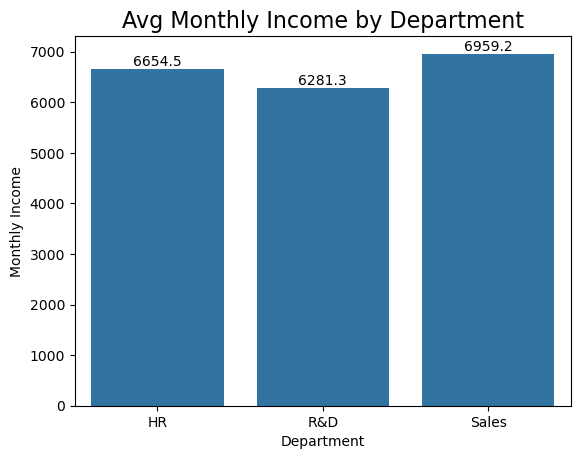

In [107]:
# Average Monthly income by Department

Avg_Income_Department = df.groupby("Department", as_index=False)["Monthly Income"].mean()

ax = sns.barplot(x="Department", y="Monthly Income", data = Avg_Income_Department)
for bar in ax.containers:
    ax.bar_label(bar, fmt="%.1f" )

plt.title("Avg Monthly Income by Department", size=16)
plt.show()

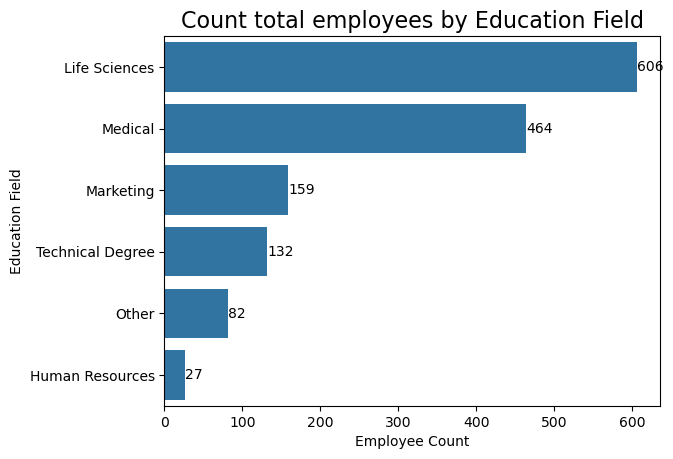

In [113]:
# Count Total Employees By Education Field

Emp_Edu_Field = df.groupby("Education Field", as_index=False)["Employee Count"].count().sort_values(by=["Employee Count"], ascending=False)

ax = sns.barplot(y = "Education Field", x = "Employee Count", data = Emp_Edu_Field)
for bar in ax.containers:
    ax.bar_label(bar)
    ax.set_title("Count total employees by Education Field", size=16)

plt.show()


#### Most employees belong to the Life Sciences and Medical education fields.

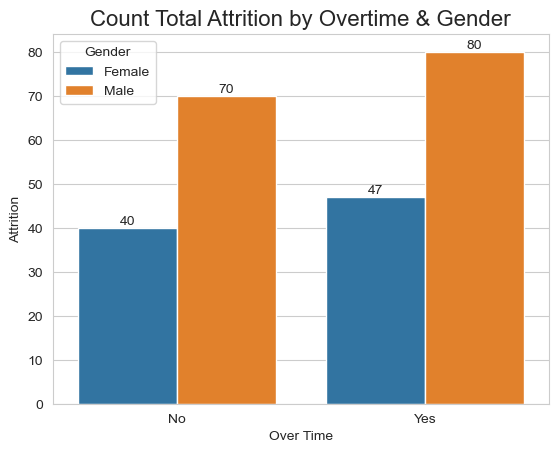

In [165]:
# Count Total Attrition by Overtime & Gender

OTA = df[df["Attrition"] == "Yes"].groupby(["Over Time", "Gender"], as_index = False)["Attrition"].count()

ax = sns.barplot(x="Over Time", y="Attrition", hue="Gender",  data = OTA)
for bar in ax.containers:
    ax.bar_label(bar)
    ax.set_title("Count Total Attrition by Overtime & Gender", size=16)

plt.show()

#### Employees working overtime showed higher attrition compared to employees without overtime.

# Conclusion

#### The highest employee attrition was observed in the R&D department, particularly among employees aged 25–34 and 35–44. Single employees and male employees contributed the highest attrition counts compared to other groups.